In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
df = pd.read_csv("Deliverable2_cleaned.csv")
df.sample(5)

,X,Y,NCESSCH,STABR,ST_LEAID,LEA_NAME,SCH_NAME,LSTREET1,LCITY,LSTATE,...,STUTERATIO,AM,AS,BL,HP,HI,TR,WH,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
32648,-91.504079,41.644102,191470001030,IA,IA-523141 000,Iowa City Comm School District,Elizabeth Tate Alt. High School,1528 Mall Drive,Iowa City,IA,...,9.26,0.000000,0.000000,44.512195,0.000000,16.463415,6.707317,29.878049,False,True
16518,-104.637600,38.256100,80612000261,CO,CO-2690,Pueblo School District No. 60 in the county of...,Heritage Elementary School,625 BROWN AVENUE,PUEBLO,CO,...,16.00,0.000000,0.000000,3.125000,0.694444,63.541667,4.166667,28.472222,True,True
15071,-104.793500,39.687900,80234001323,CO,CO-0180,Aurora Joint District No. 28 of the counties o...,Iowa Elementary School,16701 EAST IOWA AVE,AURORA,CO,...,18.50,0.831601,6.029106,19.958420,0.000000,47.817048,9.771310,15.592516,True,True
97831,-65.971047,18.254950,720003000112,PR,PR-01,PUERTO RICO DEPARTMENT OF EDUCATION,MATIAS GONZALEZ GARCIA,CALLE ANDRES ARUZ RIVERA CARR 189,GURABO,PR,...,12.48,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,True,True
69746,-97.550963,35.650501,401059002402,OK,OK-55-I012,EDMOND,WEST FIELD ES,17601 North Pennsylvania,Edmond,OK,...,18.54,2.230047,10.563380,14.319249,0.000000,11.854460,13.380282,47.652582,True,True


## 1. Identify Problem Type and Variables

Our target is Student Teacher Ratio "STUTERATIO", which is a continuous value. That make our data a regression problem.

In [38]:
# Sepearte Target and others
# 1. Isolate the features (all columns except STUTERATIO)
X = df.drop(columns=['STUTERATIO'])

# 2. Isolate the target variable
Y = df['STUTERATIO']

Y.dtype
X.TOTAL_RACE_CONS.dtype

dtype('bool')

## 2. Feature Selection

### Preparation

In [39]:
# Convert categorical ones to labels
## Split the two types of columns
X['LZIP'] = X['LZIP'].astype(str)
categorical_cols = X.select_dtypes(include=['object', 'bool'])
numerical_cols = X.select_dtypes(include=['number'])

print(f"Categorical Features: {categorical_cols.columns}")
print(f"Numerical Features: {numerical_cols.columns}")

## Label with the ones need to convert and then store the mapping in a dictionary
from sklearn.preprocessing import LabelEncoder

# 1. Use the list you manually defined
need_convert_cols = [
    'STABR', 'LSTATE', 'VIRTUAL', 'GSLO', 'GSHI', 'SCHOOL_LEVEL',
    'SCHOOL_TYPE_TEXT', 'SY_STATUS_TEXT', 'ULOCALE', 
    'TOTAL_RACE_CONS', 'TOTAL_GRADE_CONS']

label_encoders = {}
encoding_mapping = {}

# 2. Loop directly through your defined list
for col in need_convert_cols:
    # Safety check: make sure the column actually exists in df
    if col in X.columns:
        le = LabelEncoder()
        
        # Convert to string to handle any mixed types or NaNs gracefully
        X[col] = le.fit_transform(X[col].astype(str))
        
        # Store the encoder object
        label_encoders[col] = le
        
        # Store the human-readable mapping
        encoding_mapping[col] = dict(zip(le.classes_, range(len(le.classes_))))
    else:
        print(f"Warning: {col} not found in DataFrame.")


# constant drop
# from sklearn.feature_selection import VarianceThreshold
# constant_threshold = 0.2
# num_df = s.select_dtypes(include='number')
# selector = VarianceThreshold(constant_threshold)
# selector.fit(num_df)
# kept_cols = num_df.columns[selector.get_support()]
# constant_cols = num_df.columns[~selector.get_support()]

# print("Constant columns:", list(constant_cols))

Categorical Features: Index(['STABR', 'ST_LEAID', 'LEA_NAME', 'SCH_NAME', 'LSTREET1', 'LCITY',
       'LSTATE', 'LZIP', 'PHONE', 'VIRTUAL', 'GSLO', 'GSHI', 'SCHOOL_LEVEL',
       'SCHOOL_TYPE_TEXT', 'SY_STATUS_TEXT', 'ULOCALE', 'NMCNTY',
       'TOTAL_RACE_CONS', 'TOTAL_GRADE_CONS'],
      dtype='object')
Numerical Features: Index(['X', 'Y', 'NCESSCH', 'TOTFRL', 'REDLCH', 'PK', 'G01', 'G03', 'G05',
       'G06', 'G08', 'G11', 'G13', 'UG', 'AE', 'TOTMENROL', 'TOTFENROL', 'AM',
       'AS', 'BL', 'HP', 'HI', 'TR', 'WH'],
      dtype='object')


In [40]:
## Example: Peek at the mapping
print("STABR Mapping:", encoding_mapping.get('STABR', 'Not found'))
print("STABR Mapping:", encoding_mapping.get('VIRTUAL', 'Not found'))
print("STABR Mapping:", encoding_mapping.get('GSLO', 'Not found'))
print("STABR Mapping:", encoding_mapping.get('TOTAL_RACE_CONS', 'Not found'))
X.sample()

STABR Mapping: {'AK': 0, 'AL': 1, 'AR': 2, 'AZ': 3, 'CA': 4, 'CO': 5, 'CT': 6, 'DC': 7, 'DE': 8, 'FL': 9, 'GA': 10, 'HI': 11, 'IA': 12, 'ID': 13, 'IL': 14, 'IN': 15, 'KS': 16, 'KY': 17, 'LA': 18, 'MA': 19, 'MD': 20, 'ME': 21, 'MI': 22, 'MN': 23, 'MO': 24, 'MP': 25, 'MS': 26, 'MT': 27, 'NC': 28, 'ND': 29, 'NE': 30, 'NH': 31, 'NJ': 32, 'NM': 33, 'NV': 34, 'NY': 35, 'OH': 36, 'OK': 37, 'OR': 38, 'PA': 39, 'PR': 40, 'RI': 41, 'SC': 42, 'SD': 43, 'TN': 44, 'TX': 45, 'UT': 46, 'VA': 47, 'VI': 48, 'VT': 49, 'WA': 50, 'WI': 51, 'WV': 52, 'WY': 53}
STABR Mapping: {'Full Virtual': 0, 'Missing': 1, 'Not Virtual': 2, 'Supplemental Virtual': 3, 'Virtual with face to face options': 4}
STABR Mapping: {'01': 0, '02': 1, '03': 2, '04': 3, '05': 4, '06': 5, '07': 6, '08': 7, '09': 8, '10': 9, '11': 10, '12': 11, 'KG': 12, 'PK': 13, 'UG': 14}
STABR Mapping: {'False': 0, 'True': 1}


,X,Y,NCESSCH,STABR,ST_LEAID,LEA_NAME,SCH_NAME,LSTREET1,LCITY,LSTATE,...,TOTFENROL,AM,AS,BL,HP,HI,TR,WH,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
5877,-120.8652,37.7639,60006204234,4,CA-5075564,Oakdale Joint Unified,Fair Oaks Elementary,151 N. Lee Ave.,Oakdale,4,...,48.721072,0.243605,2.679659,1.218027,0.243605,37.149817,5.237515,53.227771,1,1


### a. Dropping constant or qasi-constant input features (notes from Module 5).
### b. Dropping highly correlated, i.e., redundant input features (notes from Module 5).
### c. Information Gain / Mutual Information for regression (notes from Module 8).

In [44]:
## a. Dropping constant

from sklearn.feature_selection import VarianceThreshold

# Combine your encoded cats and your numbers
X_for_testing = X[need_convert_cols + list(numerical_cols.columns)]

# Set a lower threshold for encoded/binary data (e.g., 0.01)
# 0.01 means we drop features where ~99% of values are the same
selector = VarianceThreshold(threshold=0.01) 

selector.fit(X_for_testing)

# Get the results
kept_cols = X_for_testing.columns[selector.get_support()]
constant_cols = X_for_testing.columns[~selector.get_support()]

print("Features dropped due to low variance:", list(constant_cols))
print(f"Features kept: {len(kept_cols)}")


Features dropped due to low variance: ['TOTAL_GRADE_CONS']
Features kept: 34


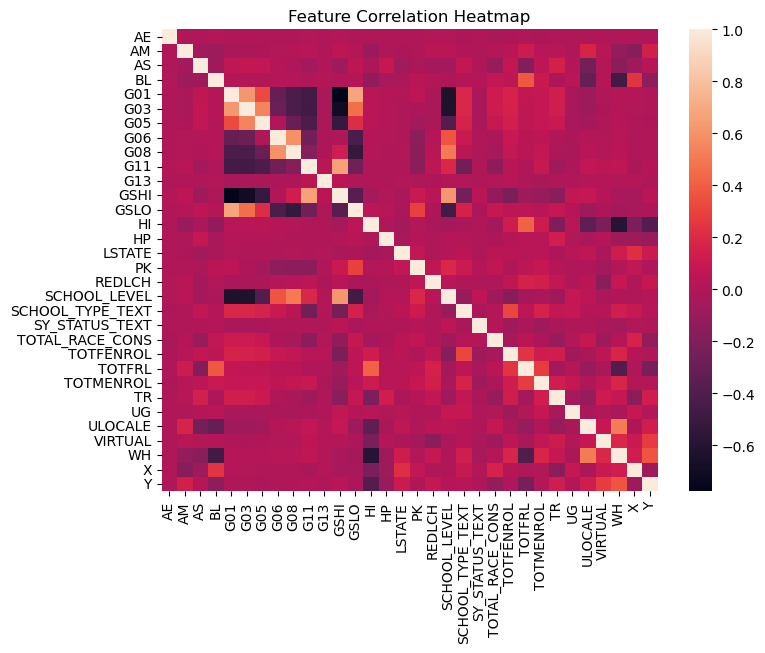

Correlated Pairs: [('GSHI', 'G01', np.float64(-0.7765698027607356))]
Kept Columns Lenth: 32
Saved P2_Deliverable1_cleaned.csv


In [55]:
## b. Dropping highly correlated

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
fig.set_size_inches(8,6)
sns.heatmap(X[kept_cols].corr())
plt.title("Feature Correlation Heatmap")
plt.show()

def find_correlated_pairs(dataset, threshold=0.7):
    corr_matrix = dataset.corr()
    correlated_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > threshold:
                correlated_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
                
    return correlated_pairs

# Find correlated pairs
correlated_pairs = find_correlated_pairs(X[kept_cols], threshold=0.7)
print("Correlated Pairs:", list(correlated_pairs))
remove_cols = ['STABR', 'NCESSCH']
print("Removing COlumns:", remove_cols)

kept_cols = kept_cols.difference(remove_cols)

print("Kept Columns Lenth:", len(kept_cols))

### Store the data
cleaned_df = pd.concat([X[kept_cols], Y], axis=1)
cleaned_df.to_csv("P2_Deliverable1_cleaned.csv", index=False)
print("Saved P2_Deliverable1_cleaned.csv")

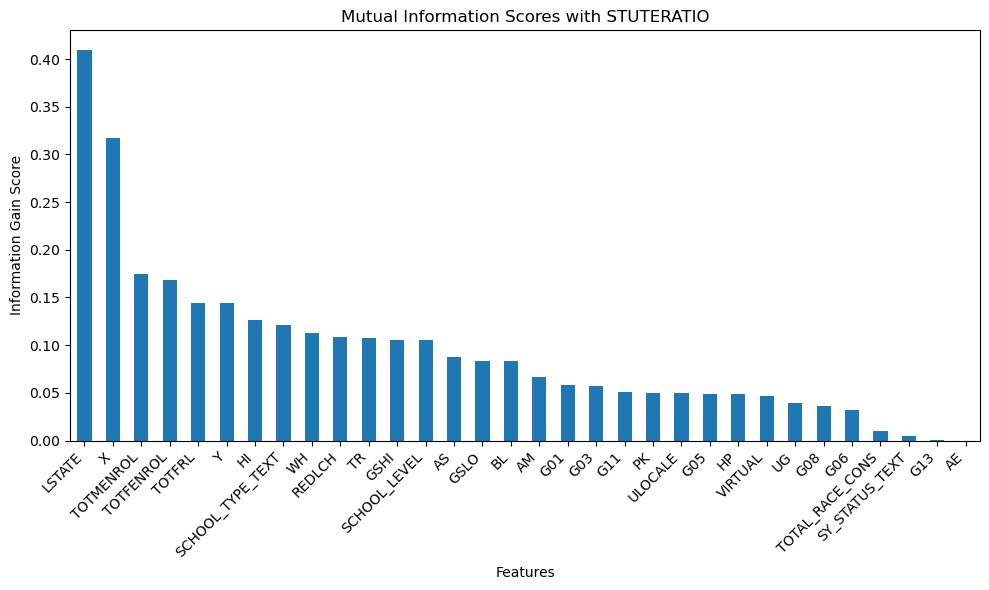

In [60]:
## c. Information Gain / Mutual Information for regression

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression

X_mi = X[kept_cols]
y_mi = Y

X_train,X_test,y_train,y_test=train_test_split(X_mi,y_mi,test_size=0.3,random_state=3)

categorical_mask = [col in need_convert_cols for col in kept_cols]
mi_scores = mutual_info_regression(X_train, y_train, discrete_features=categorical_mask, random_state=42)
mi_results = pd.Series(mi_scores, name="MI Scores", index=kept_cols)
mi_results = mi_results.sort_values(ascending=False)

## plotting
plt.figure(figsize=(10, 6))
mi_results.plot(kind='bar')

plt.title("Mutual Information Scores with STUTERATIO")
plt.ylabel("Information Gain Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [61]:
## Keeping features over 0.10

# Create a list of columns where the score is > 0.10
top_mi_cols = mi_results[mi_results > 0.10].index.tolist()

print(f"Columns with MI > 0.10: {top_mi_cols}")
print(f"Count: {len(top_mi_cols)} columns kept.")

## Update Training and Testing Sets
X_train_final = X_train[top_mi_cols]
X_test_final = X_test[top_mi_cols]

Columns with MI > 0.10: ['LSTATE', 'X', 'TOTMENROL', 'TOTFENROL', 'TOTFRL', 'Y', 'HI', 'SCHOOL_TYPE_TEXT', 'WH', 'REDLCH', 'TR', 'GSHI', 'SCHOOL_LEVEL']
Count: 13 columns kept.


## 3. Model Building

### Linear Regression

### Decision Tree Regressor


### Random Forest Regressor


### Support Vector Regressor (SVR)

## 4. Model Evaluation and Interpretation